## `crossmatch.ipynb`

This notebook does crossmatching between the sampled DESI catalog and HSC.

In [1]:
## Imports
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
import fitsio as fio

from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy.io import fits
from astropy.table import Table

In [2]:
USER_ROOT = Path('/global/cfs/cdirs/desicollab/users/jchdj')
DATA_ROOT = USER_ROOT / 'desi-y3-hsc' / 'data'
DESI_ROOT = DATA_ROOT / 'desi' / 'cat'
HSC_ROOT = DATA_ROOT / 'hsc' / 'cat'
XMATCH_ROOT = DATA_ROOT / 'xmatch'

# Find the desi file
desi_file = Path(DESI_ROOT, 'desiy3_cut_cat.fits')
print(f'DESI sampled catalog : {desi_file}')

# Find HSC data
hsc_file = Path(HSC_ROOT, 'hscy3_cat.fits')
print(f'HSC catalog : {hsc_file}')

print(f'Saving cross-matched catalog to : {XMATCH_ROOT}')

DESI sampled catalog : /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/desi/cat/desiy3_cut_cat.fits
HSC catalog : /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits
Saving cross-matched catalog to : /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/xmatch


In [3]:
# Read the HSC catalog (ETA ~ 2s)
hsc = fio.read(hsc_file)

In [ ]:
# Read the DESI catalog (ETA ~ 20-30s)
desi = fio.read(desi_file)

In [5]:
print('Loading HSC coordinates')
coords_hsc = SkyCoord(
    ra=hsc['RA'], dec=hsc['Dec'], unit=(u.deg, u.deg), frame='icrs'
    )
print('Loading DESI coordinates')
coords_desi = SkyCoord(
    ra=desi['TARGET_RA'], dec=desi['TARGET_DEC'], unit=(u.deg, u.deg), frame='icrs'
    )

Loading HSC coordinates
Loading DESI coordinates


# Crossmatch the two catalogs

Syntax : 
`idx, d2d, _ = cat1.match_to_catalog_sky(cat2, **kwargs)`  

Returns : 
- `idx` : index of cat2 that are the closest entry to cat1
- `d2d` : angular separation between the two coordinates

Since HSC is much deeper than DESI, we can expect all DESI spectra in HSC's footprint to have a match in HSC. Outside of HSC's footprint, we'll have to exclude the matched rows of DESI.

In [6]:
# Perform the crossmatch, assuming HSC is deeper than DESI (ETA ~ 1min)	
idx, d2d, _ = coords_desi.match_to_catalog_sky(coords_hsc)

In [78]:
# Setting a maximum separation of 0.2 arcsec between two targets when crossmatching
max_sep = 0.8 * u.arcsec
sep_constraint = d2d < max_sep

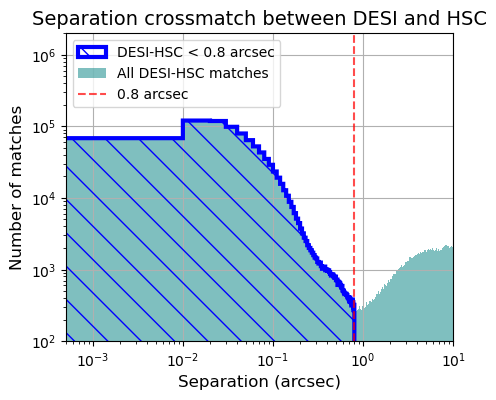

In [79]:
# Plotting separation histogram based on the crossmatch
plt.figure(figsize=(5, 4))
xmatch_bins = np.linspace(0, 50, 5000)
plt.hist(
    d2d[sep_constraint].arcsec, 
    bins=xmatch_bins, 
    alpha=1, 
    histtype='step', 
    color='blue', 
    hatch='\\',
    linewidth=3,
    label=f'DESI-HSC < {max_sep}'
    )
plt.hist(
    d2d.arcsec, 
    bins=xmatch_bins, 
    alpha=0.5, 
    color='teal',
    label='All DESI-HSC matches'
    )
plt.axvline(
    max_sep.to(u.arcsec).value, 
    color='red', 
    linestyle='--', 
    label=f'{max_sep}',
    alpha=0.7
    )
plt.xlabel('Separation (arcsec)', fontsize=12)
plt.ylabel('Number of matches', fontsize=12)
plt.title('Separation crossmatch between DESI and HSC', fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.xlim(5e-4, 1e1)
plt.ylim(1e2, 2e6)
plt.legend(fontsize=10, loc='upper left')
plt.grid()

In [80]:
# Getting the matched coordinates between the two catalogs
desi_matches = coords_desi[sep_constraint]
hsc_matches = coords_hsc[idx[sep_constraint]]
print(len(desi_matches), 'DESI targets matched with HSC')
print(len(hsc_matches), 'HSC targets matched with DESI')

879249 DESI targets matched with HSC
879249 HSC targets matched with DESI


In [81]:
# Matching indices between the two catalogs
print(np.flatnonzero(sep_constraint))
print(idx[sep_constraint])

[   17479    34656   181201 ... 24325851 24325853 24325855]
[ 3469502   706455 10088271 ... 21194593 21184963 21185673]


In [82]:
## Saving output catalogs based on separation indices
desi_xmatch_file = Path(XMATCH_ROOT, 'desi_xm_hsc_sep0_8.fits')
hsc_xmatch_file = Path(XMATCH_ROOT, 'hsc_xm_desi_sep0_8.fits')

In [83]:
desi_xmatch = Table(desi[sep_constraint])
hsc_xmatch = Table(hsc[idx[sep_constraint]])

In [84]:
desi_xmatch['HSC_ROW_MATCH'] = idx[sep_constraint]
hsc_xmatch['DESI_ROW_MATCH'] = np.flatnonzero(sep_constraint)
# Save the matched catalogs
hsc_xmatch.write(hsc_xmatch_file, overwrite=True)
print(f'HSC matched catalog saved to {hsc_xmatch_file}')
desi_xmatch.write(desi_xmatch_file, overwrite=True)
print(f'DESI matched catalog saved to {desi_xmatch_file}')

HSC matched catalog saved to /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/xmatch/hsc_xm_desi_sep0_8.fits
DESI matched catalog saved to /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/xmatch/desi_xm_hsc_sep0_8.fits


In [85]:
ra_desi = desi_matches.ra.rad
dec_desi = desi_matches.dec.rad
ra_hsc = hsc_matches.ra.rad
dec_hsc = hsc_matches.dec.rad

Finished plotting DESI coordinates
Finished plotting HSC coordinates


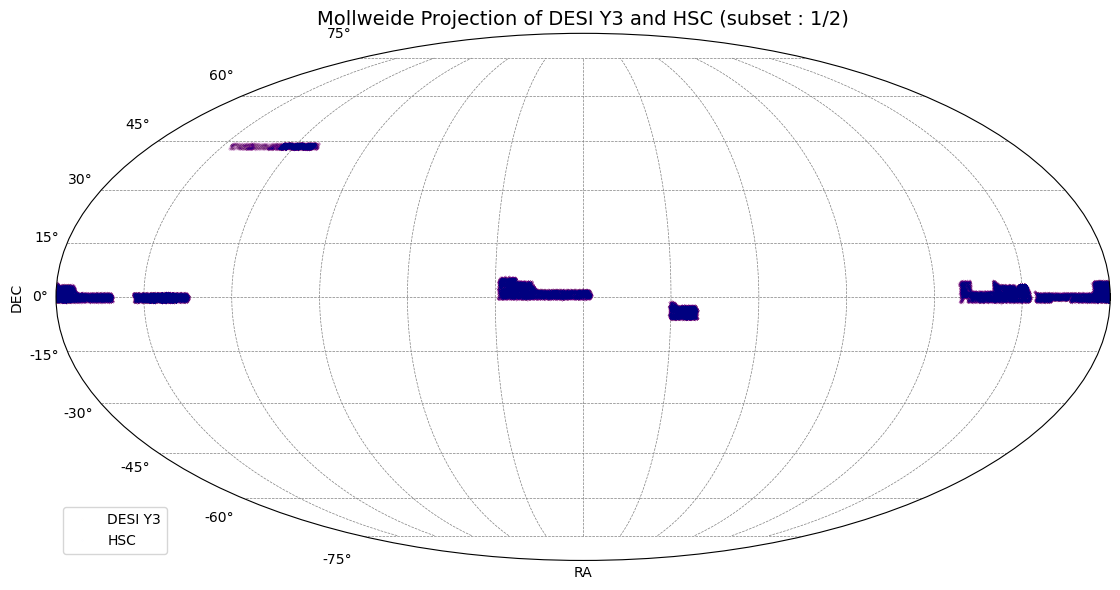

In [86]:
# Plotting the coordinates of the matched catalogs
sample_rate = 2
# Wrap RA coordinates to [-pi, pi]
ra_desi_wr = np.remainder(ra_desi[0::sample_rate] + np.pi, 2*np.pi) - np.pi
ra_hsc_wr = np.remainder(ra_hsc[0::sample_rate] + np.pi, 2*np.pi) - np.pi

plt.figure(figsize=(12, 6))
ax = plt.subplot(111, projection='mollweide')
ax.plot(ra_desi_wr, dec_desi[0::sample_rate], 'r.', markersize=0.03, label='DESI Y3', alpha=0.3)
print(f'Finished plotting DESI coordinates')
ax.plot(ra_hsc_wr, dec_hsc[0::sample_rate], 'b.', markersize=0.03, label='HSC', alpha=0.3)
print(f'Finished plotting HSC coordinates')

ax.grid(color='gray', linestyle='--', linewidth=0.5)
ax.set_xticklabels([])
ax.legend(loc='lower left', fontsize=10)
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
plt.title(f'Mollweide Projection of DESI Y3 and HSC (subset : 1/{sample_rate})', fontsize=14)
plt.tight_layout()
plt.show()

In [72]:
## Let's zoom on a specifc region of the crossmatch
bounds = [
    [179, 181], # RA
    [1, 3], # DEC
    ]
def spatial_bounds(coords, bounds):
    """
    Function to select coordinates based on spatial bounds
    """
    ra = coords.ra.deg
    dec = coords.dec.deg
    mask = (
        ((ra > bounds[0][0]) & (ra < bounds[0][1])) &
        ((dec > bounds[1][0]) & (dec < bounds[1][1]))
        )
    return mask

In [73]:
# Compute xmatch bounded coords
desi_xmatch_coords_b = desi_matches[spatial_bounds(desi_matches, bounds)]
hsc_xmatch_coords_b = hsc_matches[spatial_bounds(hsc_matches, bounds)]

In [74]:
# Compute full sample bounded coords
desi_coords_b = coords_desi[spatial_bounds(coords_desi, bounds)]
hsc_coords_b = coords_hsc[spatial_bounds(coords_hsc, bounds)]

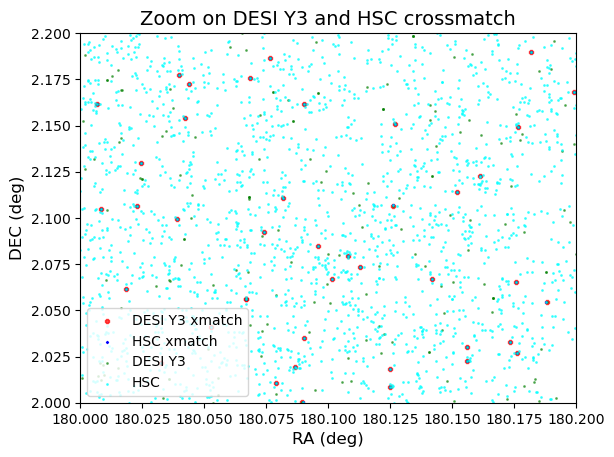

In [75]:
sample_rate_b = 2
plt.scatter(
    desi_xmatch_coords_b.ra.deg, 
    desi_xmatch_coords_b.dec.deg, 
    color='red',
    marker='P', 
    s=5, 
    label='DESI Y3 xmatch', 
    alpha=0.7
    )
plt.scatter(
    hsc_xmatch_coords_b.ra.deg, 
    hsc_xmatch_coords_b.dec.deg, 
    color='blue',
    marker='D',
    s=1, 
    label='HSC xmatch', 
    alpha=1
    )
plt.scatter(
    desi_coords_b.ra.deg, 
    desi_coords_b.dec.deg, 
    color='green', 
    marker='X',
    s=1, 
    label='DESI Y3', 
    alpha=0.5
    )
plt.scatter(
    hsc_coords_b.ra.deg, 
    hsc_coords_b.dec.deg, 
    color='cyan', 
    marker='X',
    s=1, 
    label='HSC', 
    alpha=0.6
    )
center_ra = bounds[0][0] + (bounds[0][1] - bounds[0][0]) / 2
center_dec = bounds[1][0] + (bounds[1][1] - bounds[1][0]) / 2
zoom = 0.1
offset = 0.1
plt.xlim(center_ra-zoom+offset, center_ra+zoom+offset)
plt.ylim(center_dec-zoom+offset, center_dec+zoom+offset)
plt.xlabel('RA (deg)', fontsize=12)
plt.ylabel('DEC (deg)', fontsize=12)
plt.title(f'Zoom on DESI Y3 and HSC crossmatch', fontsize=14)
plt.legend(loc='lower left', fontsize=10)

In [77]:
# Possible bias in the crossmatch ?
print(
    np.mean(desi_matches.ra.deg - hsc_matches.ra.deg), 
    np.mean(desi_matches.dec.deg - hsc_matches.dec.deg)
    )

-1.0640773731477068e-06 -3.4535233880018505e-06
